# TRAS - Photobleached

### Mounting the google drive

In [ ]:
# To begin, we import some libraries that we will need later.

# Some handy standard python libraries
import os

# The numpy library is very useful for many things
import numpy as np
import pandas as pd

# The pyplot module from matplotlib will allow us to plot things.
from matplotlib import pyplot as plt
from scipy.optimize import curve_fit
from math import pi

In [ ]:
# Connect (mount) your google drive as a virtual directory accessible by this python code.
from google.colab import drive         # Import the python module that allows you to access your google drive
rootpathdrive = '/content/drive'       # This will be the directory as which your google drive will be known
drive.mount(rootpathdrive)             # Now connect to this google drive.

# At first use it will ask you to click on a link, after which you should give permission
# for outside processes to access your google drive. A authorization code is generated which should be entered
#(this is explained in https://colab.research.google.com/notebooks/io.ipynb#scrollTo=XDg9OBaYqRMd).

Mounted at /content/drive


In [ ]:
# # A good test to do is if you can see the contents of the directory in which you work on your google drive.
# # Here "My Drive" refers to the "root" of your google drive.
# # By default your notebook should be in a directory called Colab Notebooks.
# # This template assumes all files you want to read in are copied in the
# # same directory. Note the slash at the end of the first line.

# #==============================================================================================================
# #pathTRAS = rootpathdrive+'/'+'My Drive/Year 3 Lab/Pulsar/Crab_pulsar_template/' # Fin's Directory
# #pathTRAS = rootpathdrive+'/'+'My Drive/Year 3 Lab/Pulsar/CrabPulsar/Crab_pulsar_template' #Fin's 2
pathTRAS = rootpathdrive+'/'+'My Drive/Colab Notebooks/TRAS/Photobleach' #Sara's directory
# #==============================================================================================================

filelist = []
for (dirpath, dirnames, filenames) in os.walk(pathTRAS):
    filelist.extend(filenames)
    break
print (filelist)   # Show the contents of your working directory. At least your notebook should show up here.


['Photobleached_BZ01.ipynb', 'PhotobleachBZC1_2026-03-17 16-50-35 TA.csv', 'PhotobleachBZC1_2026-03-17 16-50-35 TA_traces.csv', 'PhotobleachBZC1_2026-03-17 16-50-35 TA.xml', 'PhotobleachBZC1_2026-03-17 16-50-35 TA_signal_vs_time.png', 'Photobleached_BZC1.ipynb', 'BZ01_Photobleached_2026-03-24 14-56-41 TA.xml', 'BZ01_Photobleached_2026-03-24 14-56-41 TA.csv', 'BZ01_Photobleached_2026-03-24 14-56-41 TA_traces.csv']


## Loading and cleaning data
This step removes the negative bits before the exponential decay.

In [5]:
csv_title = 'BZ01_Photobleached_2026-03-24 14-56-41 TA.csv' #Modify this
clean_title = csv_title.replace(".csv", "")

df = pd.read_csv(
    os.path.join(pathTRAS, csv_title),
    sep=";",
    header=None,
    names=["time", "signal"]
)

df.head()

df = df.iloc[1:].reset_index(drop=True)
df = df.astype(float)

# index of maximum signal
idx_peak = df["signal"].idxmax()
df = df.loc[idx_peak:].reset_index(drop=True)


time = df["time"].to_numpy()
signal = df["signal"].to_numpy()

## Fitting an exponential

Bootstrap Bill

In [6]:
# Exponential fit
def exp_decay(t, A, tau, C):
    return A * np.exp(-t / tau) + C

# Data - signal against time
x = time
y = signal

# Initial guesses based on max and min of dataset and bounds
A_init = y.max() - y.min()
tau_init = (x.max() - x.min()) / 5
C_init = y.min()
p0 = [A_init, tau_init, C_init] # Combined parameter for the 3 values
bounds = ([-np.inf, 0, -np.inf], [np.inf, np.inf, np.inf])

# Fit the exponential curve on the dataset and obtain error from covariance matrix
popt, pcov = curve_fit(exp_decay, x, y, p0=p0, bounds=bounds)
A, tau, C = popt
param_error = np.sqrt(np.diag(pcov))
A_error, tau_error, C_error = param_error

# Residuals
y_fit_data = exp_decay(x, *popt)
residuals = y - y_fit_data

# Bootstrapping
n_boot = 5000
tau_boot = []

for _ in range(n_boot):
    # Resample residuals with replacement
    resampled_residuals = np.random.choice(residuals, size=len(residuals), replace=True)

    # Generate bootstrap dataset
    y_boot = y_fit_data + resampled_residuals

    try:
        # Refit
        popt_boot, _ = curve_fit(exp_decay, x, y_boot, p0=popt, bounds=bounds)
        tau_boot.append(popt_boot[1])
    except RuntimeError:
        # Skip failed fits
        continue

tau_boot = np.array(tau_boot)

# --- Bootstrap statistics ---
tau_std = np.std(tau_boot)
ci_low, ci_high = np.percentile(tau_boot, [2.5, 97.5])

print(f"Best-fit tau = {tau:.3f} ns")
print(f"Bootstrap standard error = {tau_std:.3f} ns")
print(f"95% CI = [{ci_low:.3f}, {ci_high:.3f}] ns")


Best-fit tau = 916.499 ns
Bootstrap standard error = 3.094 ns
95% CI = [910.581, 922.671] ns


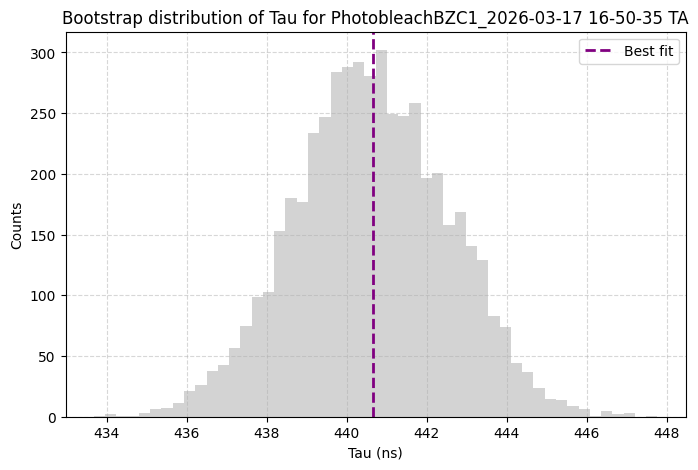

In [ ]:
plt.figure(figsize=(8, 5))

plt.hist(
    tau_boot,
    bins=50,
    facecolor='#D3D3D3',     # inside of bars
    #edgecolor='white',   # purple outline
    linewidth=1.5,         # thickness of the outline
    alpha=1.0              # fully opaque inside (white)
)

# Add vertical line for best-fit tau
plt.axvline(tau, color='purple', linestyle='--', linewidth=2, label='Best fit')

plt.xlabel("Tau (ns)")
plt.ylabel("Counts")
plt.title(f"Bootstrap distribution of Tau for {clean_title}")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.savefig(
    f"/content/drive/MyDrive/Colab Notebooks/TRAS/C70_17Feb2026/{clean_title}_Bootstrap_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [ ]:
print(A, tau, C)

18.305411095008612 440.6470835339082 3.9554570184622566


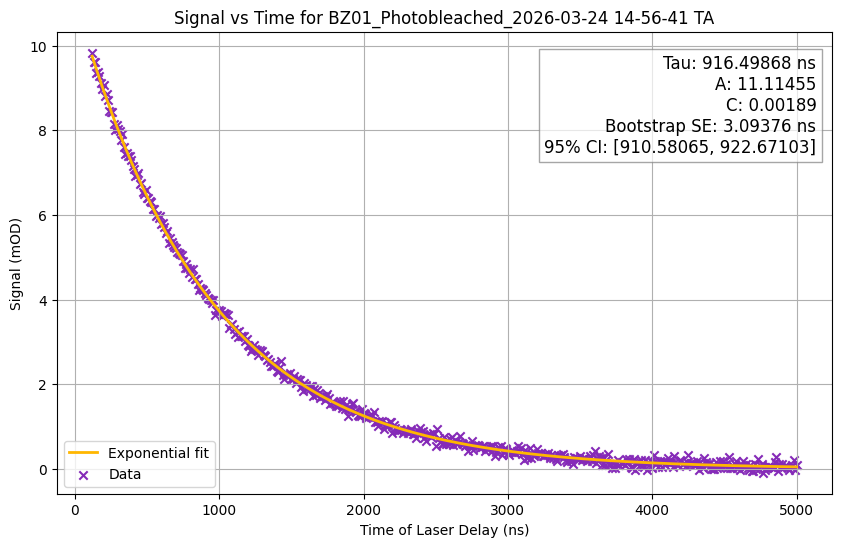


=== Stern–Volmer preparation values ===
Concentration (you fill manually per sample): [insert here]
Tau value (ns): 916.49868
Tau bootstrap SE (ns): 3.09376
Tau 95% CI low (ns): 910.58065
Tau 95% CI high (ns): 922.67103


In [7]:
# --- Create fine x-axis for smooth fitted curve ---
x_fit = np.linspace(x.min(), x.max(), 1000)
y_fit = exp_decay(x_fit, *popt)

plt.figure(figsize=(10, 6))

# Plot the exponential fit
plt.plot(x_fit, y_fit, color='#FFB700', linewidth=2, label='Exponential fit')

# Plot the data points
plt.scatter(x, y, marker='x', color='#852AB8', label='Data')

# Title and labels
plt.title(f'Signal vs Time for {clean_title}')
plt.xlabel('Time of Laser Delay (ns)')
plt.ylabel('Signal (mOD)')

# Add best-fit parameters as text
plt.text(
    0.98, 0.95,
    f'Tau: {tau:.5f} ns\nA: {A:.5f}\nC: {C:.5f}\nBootstrap SE: {tau_std:.5f} ns\n95% CI: [{ci_low:.5f}, {ci_high:.5f}]',
    transform=plt.gca().transAxes,  # axes coordinates
    ha='right',
    va='top',
    fontsize=12,
    color='black',
    bbox=dict(facecolor='white', alpha=0.7, edgecolor='gray')
)

plt.legend()
plt.grid(True)

# Save figure
plt.savefig(
    f"/content/drive/MyDrive/Colab Notebooks/TRAS/Photobleach/{clean_title}_signal_vs_time.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# --- Output values for Stern-Volmer preparation ---
print("\n=== Stern–Volmer preparation values ===")
print(f"Concentration (you fill manually per sample): [insert here]")
print(f"Tau value (ns): {tau:.5f}")
print(f"Tau bootstrap SE (ns): {tau_std:.5f}")
print(f"Tau 95% CI low (ns): {ci_low:.5f}")
print(f"Tau 95% CI high (ns): {ci_high:.5f}")


# Values Obtained

=== Stern–Volmer preparation values ===
Concentration BZC1: [insert here]
Tau value (ns): 467.37783
Tau bootstrap SE (ns): 1.60444
Tau 95% CI low (ns): 464.25428
Tau 95% CI high (ns): 470.52153


=== Stern–Volmer preparation values ===
Concentration BZC075: [insert here]
Tau value (ns): 498.67187
Tau bootstrap SE (ns): 1.44686
Tau 95% CI low (ns): 495.84387
Tau 95% CI high (ns): 501.4426

=== Stern–Volmer preparation values ===
Concentration BZC05: [insert here]
Tau value (ns): 608.80600
Tau bootstrap SE (ns): 1.29290
Tau 95% CI low (ns): 606.30114
Tau 95% CI high (ns): 611.36303

=== Stern–Volmer preparation values ===
Concentration BZC025: [insert here]
Tau value (ns): 688.46917
Tau bootstrap SE (ns): 1.58258
Tau 95% CI low (ns): 685.31760
Tau 95% CI high (ns): 691.53833

=== Stern–Volmer preparation values ===
Concentration BZC01: [insert here]
Tau value (ns): 789.54620
Tau bootstrap SE (ns): 1.48348
Tau 95% CI low (ns): 786.68959
Tau 95% CI high (ns): 792.44233

In [ ]:
unc_from_base = 0.1**2
base2 = np.array([1, 0.75, 0.5, 0.25, 0.1])
solvent = np.array([1e-12, 0.25, 0.5, 0.75, 0.9])


conc_err = np.sqrt(
    unc_from_base +
    (0.1/base2)**2 +
    (0.1/solvent)**2
)

conc_err[0] = np.sqrt(2)/10
print(conc_err)



[0.14142136 0.43333333 0.3        0.43333333 1.01111111]


## Stern Volmer plot
Described on page 22 of the physical manual, gradient gives k_q

Stern–Volmer slope (Ksv): 9.96726e-04 1/ns·mM ± 4.68006e-05
Intercept: 1.18301e-03


<Figure size 1000x600 with 0 Axes>

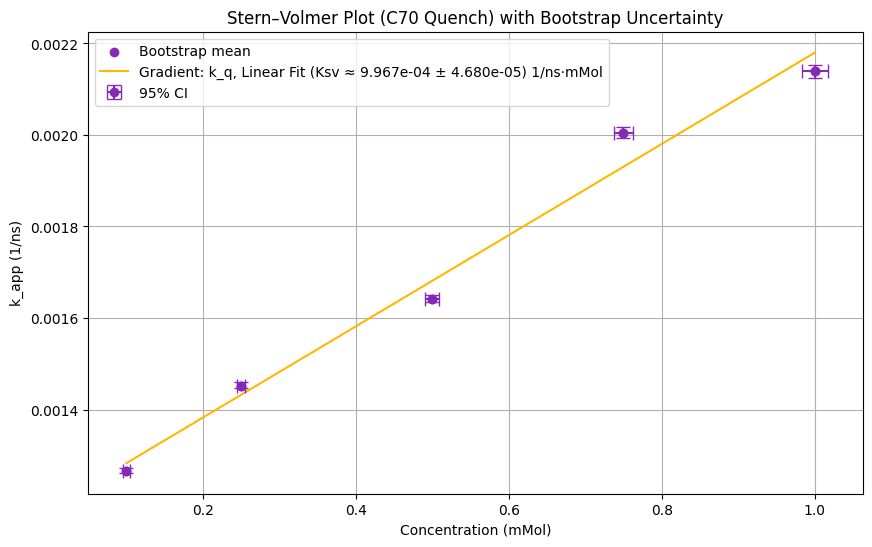

In [ ]:
# # # Array prep
# Concentrations (BZC1 → 1 mM … BZ01 → 0.1 mM)
concentrations = np.array([1, 0.75, 0.5, 0.25, 0.1])
tau_values = np.array([467.37783, 498.67187, 608.80600, 688.46917, 789.54620])
tau_std_values = np.array([1.60444, 1.44686, 1.29290,1.58258, 1.48348]) #Bootstrap errors


# Tau 95% CI low/high (ns)
tau_CI_low = np.array([464.25428, 495.84387, 606.30114 , 685.31760, 786.68959])
tau_CI_high = np.array([470.52153, 501.4426,  611.36303,  691.53833, 792.44233])


#k_app = 1 / tau
k_app = 1 / tau_values  # units 1/ns
k_app_SE = tau_std_values / (tau_values**2)  # propagate SE
k_app_CI_low = 1 / tau_CI_high  # lower bound for 1/tau
k_app_CI_high = 1 / tau_CI_low  # upper bound for 1/tau


#Bootstrapped derived slope
# Simple linear fit for SV slope
coeff = np.polyfit(concentrations, k_app, 1)
k_sv_slope = coeff[0]  # slope = Ksv
intercept = coeff[1]

# Optional: calculate gradient uncertainty via simple bootstrap (propagating k_app_CI)
# We'll just estimate ± from the CI ranges roughly
k_app_CI_width = k_app_CI_high - k_app_CI_low
# rough approximation of slope uncertainty
k_sv_slope_error = np.sqrt(np.sum((k_app_CI_width / (concentrations.max() - concentrations.min()))**2))

#conc_err = [0.14142136, 0.43333333, 0.3,        0.43333333, 1.01111111]
conc_err = [1.685e-2, 1.291e-2, 9.11e-3, 5.72e-3, 4.322e-3]
#Plotting
plt.figure(figsize=(10, 6))

print(f"Stern–Volmer slope (Ksv): {k_sv_slope:.5e} 1/ns·mM ± {k_sv_slope_error:.5e}")
print(f"Intercept: {intercept:.5e}")

# Plotting (same as before)
plt.figure(figsize=(10, 6))

plt.scatter(concentrations, k_app, color='#852AB8', label='Bootstrap mean', zorder=5)
plt.errorbar(
    concentrations,
    k_app,
    xerr=conc_err,
    yerr=[k_app - k_app_CI_low, k_app_CI_high - k_app],
    fmt='o',
    color='#852AB8',
    capsize=5,
    label='95% CI',
    zorder=4
)

x_fit = np.linspace(concentrations.min(), concentrations.max(), 100)
plt.plot(x_fit, np.polyval(coeff, x_fit), color='#FFB700',
         label=f'Gradient: k_q, Linear Fit (Ksv ≈ {k_sv_slope:.3e} ± {k_sv_slope_error:.3e}) 1/ns·mMol')

plt.xlabel("Concentration (mMol)")
plt.ylabel("k_app (1/ns)")
plt.title("Stern–Volmer Plot (C70 Quench) with Bootstrap Uncertainty")
plt.grid(True)
plt.legend()

# Save figure
plt.savefig(
    f"/content/drive/MyDrive/Colab Notebooks/TRAS/C70_17Feb2026/C70_SternVolmer.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



=== Weighted polyfit (covariance matrix) ===
  Ksv (slope)  : 1.17446e-04  ±  2.53324e-06  1/ns·mM
  k1 (intercept): 1.08002e-03  ±  1.63541e-06  1/ns

=== Bootstrap cross-check (n=10,000) ===
  Ksv  : 1.16029e-04  ±  8.27891e-06  | 95% CI [1.00017e-04, 1.32277e-04]
  k1   : 1.08057e-03  ±  4.95036e-06  | 95% CI [1.07084e-03, 1.09017e-03]


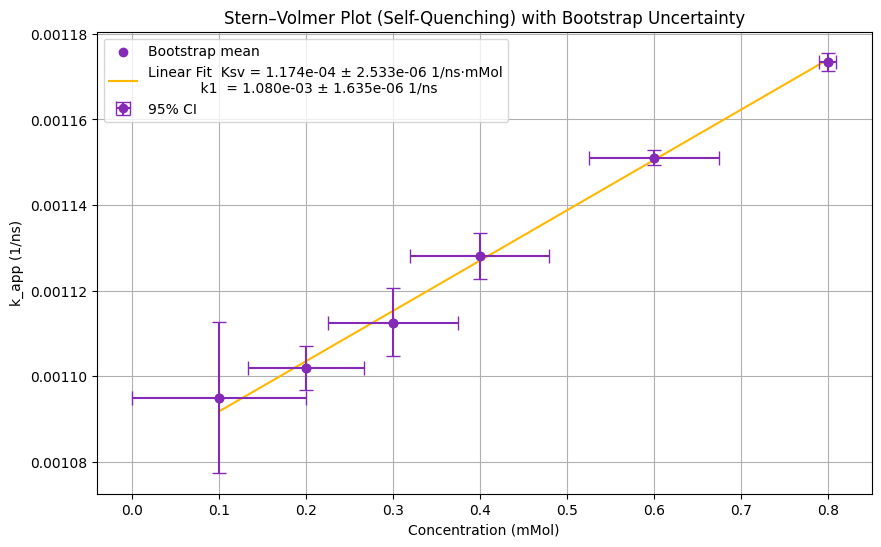

In [ ]:
# Array prep
# Concentrations (BZ08 → 0.8 mM … BZ01 → 0.1 mM)
concentrations = np.array([0.8, 0.6, 0.4, 0.3, 0.2, 0.1])
tau_values = np.array([852.22356, 868.76250, 886.48941, 898.85662, 907.50005, 913.34809])
tau_std_values = np.array([0.80758, 0.68813, 2.17208, 3.27438, 2.18130, 7.50122])

# Tau 95% CI low/high (ns)
tau_CI_low  = np.array([850.65059, 867.41159, 882.20551, 892.43311, 903.21945, 898.70783])
tau_CI_high = np.array([853.80531, 870.10510, 890.74130, 905.24706, 911.80480, 928.08607])

# k_app = 1/tau with propagated uncertainties
k_app        = 1 / tau_values
k_app_SE     = tau_std_values / (tau_values**2)
k_app_CI_low = 1 / tau_CI_high
k_app_CI_high= 1 / tau_CI_low

conc_err = np.array([0.01, 0.075, 0.08, 0.075, 0.067, 0.1])

# ── Slope & intercept via np.polyfit with covariance ──────────────────────────
# Using k_app_SE as weights (w = 1/sigma) for weighted least squares
weights = 1 / k_app_SE  # inverse-sigma weighting

coeff, cov = np.polyfit(concentrations, k_app, 1, w=weights, cov=True)
k_sv_slope  = coeff[0]
intercept   = coeff[1]

# Standard errors directly from the covariance matrix diagonal
k_sv_slope_err  = np.sqrt(cov[0, 0])
intercept_err   = np.sqrt(cov[1, 1])

# ── Bootstrap uncertainty cross-check ─────────────────────────────────────────
n_boot = 10_000
rng = np.random.default_rng(42)

boot_slopes     = np.empty(n_boot)
boot_intercepts = np.empty(n_boot)

for i in range(n_boot):
    # Resample k_app values within their SE (Gaussian noise)
    k_boot = k_app + rng.normal(0, k_app_SE, size=len(k_app))
    c_boot, _ = np.polyfit(concentrations, k_boot, 1, cov=False), None
    # polyfit returns array; unpack
    c_boot = np.polyfit(concentrations, k_boot, 1)
    boot_slopes[i]     = c_boot[0]
    boot_intercepts[i] = c_boot[1]

boot_slope_std     = np.std(boot_slopes,     ddof=1)
boot_intercept_std = np.std(boot_intercepts, ddof=1)

# 95% CI from bootstrap percentiles
slope_CI     = np.percentile(boot_slopes,     [2.5, 97.5])
intercept_CI = np.percentile(boot_intercepts, [2.5, 97.5])

# ── Print results ──────────────────────────────────────────────────────────────
print("=== Weighted polyfit (covariance matrix) ===")
print(f"  Ksv (slope)  : {k_sv_slope:.5e}  ±  {k_sv_slope_err:.5e}  1/ns·mM")
print(f"  k1 (intercept): {intercept:.5e}  ±  {intercept_err:.5e}  1/ns")

print("\n=== Bootstrap cross-check (n=10,000) ===")
print(f"  Ksv  : {np.mean(boot_slopes):.5e}  ±  {boot_slope_std:.5e}  "
      f"| 95% CI [{slope_CI[0]:.5e}, {slope_CI[1]:.5e}]")
print(f"  k1   : {np.mean(boot_intercepts):.5e}  ±  {boot_intercept_std:.5e}  "
      f"| 95% CI [{intercept_CI[0]:.5e}, {intercept_CI[1]:.5e}]")

# ── Plot ───────────────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 6))

plt.scatter(concentrations, k_app, color='#852AB8', label='Bootstrap mean', zorder=5)
plt.errorbar(
    concentrations, k_app,
    xerr=conc_err,
    yerr=[k_app - k_app_CI_low, k_app_CI_high - k_app],
    fmt='o', color='#852AB8', capsize=5, label='95% CI', zorder=4
)

x_fit = np.linspace(concentrations.min(), concentrations.max(), 100)
plt.plot(x_fit, np.polyval(coeff, x_fit), color='#FFB700',
         label=(f'Linear Fit  Ksv = {k_sv_slope:.3e} ± {k_sv_slope_err:.3e} 1/ns·mMol\n'
                f'            k1  = {intercept:.3e} ± {intercept_err:.3e} 1/ns'))

plt.xlabel("Concentration (mMol)")
plt.ylabel("k_app (1/ns)")
plt.title("Stern–Volmer Plot (Self-Quenching) with Bootstrap Uncertainty")
plt.grid(True)
plt.legend()

plt.savefig(
    "/content/drive/MyDrive/Colab Notebooks/TRAS/Self_Quenching_17Feb2026/SelfQuenching_SternVolmer.png",
    dpi=300, bbox_inches="tight"
)
plt.show()